# Exercice 3 - Deep Q-Network avec CartPole-v1

Objectif : implémenter un DQN sur `CartPole-v1` de deux façons : d'abord manuellement avec PyTorch, puis avec Stable-Baselines3.

## Pourquoi un DQN ?

Dans l'exercice précédent, `FrozenLake-v1` avait un petit nombre d'états discrets. Une Q-table suffisait donc pour mémoriser la valeur de chaque action dans chaque état.

`CartPole-v1` est différent : l'observation contient quatre valeurs continues. Il serait impossible de créer une Q-table simple pour toutes les combinaisons possibles. Le DQN remplace donc la Q-table par un réseau de neurones qui approxime les valeurs Q.

## Étape 1 - Définir le réseau DQN et le Replay Buffer

Le réseau prédit une valeur Q pour chaque action possible. Le `ReplayBuffer` stocke les expériences passées afin d'entraîner le réseau sur des mini-batchs tirés aléatoirement.

In [1]:
from collections import deque
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F


sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


In [2]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [3]:
env = gym.make("CartPole-v1")
env.action_space.seed(SEED)

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

demo_model = DQN(state_size, action_size)
print("Taille d'un état :", state_size)
print("Nombre d'actions :", action_size)
print(demo_model)

demo_buffer = ReplayBuffer(capacity=10)
demo_buffer.push(np.zeros(state_size), 0, 1.0, np.ones(state_size), False)
print("Exemple de batch du ReplayBuffer :", demo_buffer.sample(1))

env.close()

Taille d'un état : 4
Nombre d'actions : 2
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)
Exemple de batch du ReplayBuffer : [(array([0., 0., 0., 0.]), 0, 1.0, array([1., 1., 1., 1.]), False)]


## Étape 2 - Entraîner un DQN manuel

Le `policy_net` choisit les actions et apprend à prédire les valeurs Q. Le `target_net` sert de référence plus stable pour calculer les valeurs cibles. Il est synchronisé périodiquement avec le `policy_net`.

In [4]:
BATCH_SIZE = 64
GAMMA = 0.99
LEARNING_RATE = 1e-3
BUFFER_CAPACITY = 10_000
NUM_EPISODES = 250
TARGET_UPDATE_FREQUENCY = 10

EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995

env = gym.make("CartPole-v1")
env.action_space.seed(SEED)

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

policy_net = DQN(state_size, action_size).to(device)
target_net = DQN(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = torch.optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
replay_buffer = ReplayBuffer(BUFFER_CAPACITY)
loss_fn = nn.SmoothL1Loss()


def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()

    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = policy_net(state_tensor)
    return int(q_values.argmax(dim=1).item())


def optimize_model():
    if len(replay_buffer) < BATCH_SIZE:
        return None

    batch = replay_buffer.sample(BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.array(states)).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones = torch.BoolTensor(dones).to(device)

    current_q_values = policy_net(states).gather(1, actions).squeeze(1)

    with torch.no_grad():
        next_q_values = target_net(next_states).max(1)[0]
        next_q_values[dones] = 0.0
        target_q_values = rewards + GAMMA * next_q_values

    loss = loss_fn(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

    return loss.item()

In [5]:
episode_rewards = []
episode_losses = []
epsilon = EPSILON_START

for episode in range(1, NUM_EPISODES + 1):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0
    losses = []

    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        loss = optimize_model()

        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    episode_rewards.append(total_reward)
    episode_losses.append(np.mean(losses) if losses else np.nan)

    if episode % TARGET_UPDATE_FREQUENCY == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % 50 == 0:
        mean_reward = np.mean(episode_rewards[-50:])
        print(f"Épisode {episode:3d} | récompense moyenne sur 50 épisodes : {mean_reward:.1f} | epsilon : {epsilon:.3f}")

env.close()

Épisode  50 | récompense moyenne sur 50 épisodes : 26.1 | epsilon : 0.778
Épisode 100 | récompense moyenne sur 50 épisodes : 42.6 | epsilon : 0.606
Épisode 150 | récompense moyenne sur 50 épisodes : 40.7 | epsilon : 0.471
Épisode 200 | récompense moyenne sur 50 épisodes : 44.7 | epsilon : 0.367
Épisode 250 | récompense moyenne sur 50 épisodes : 46.4 | epsilon : 0.286


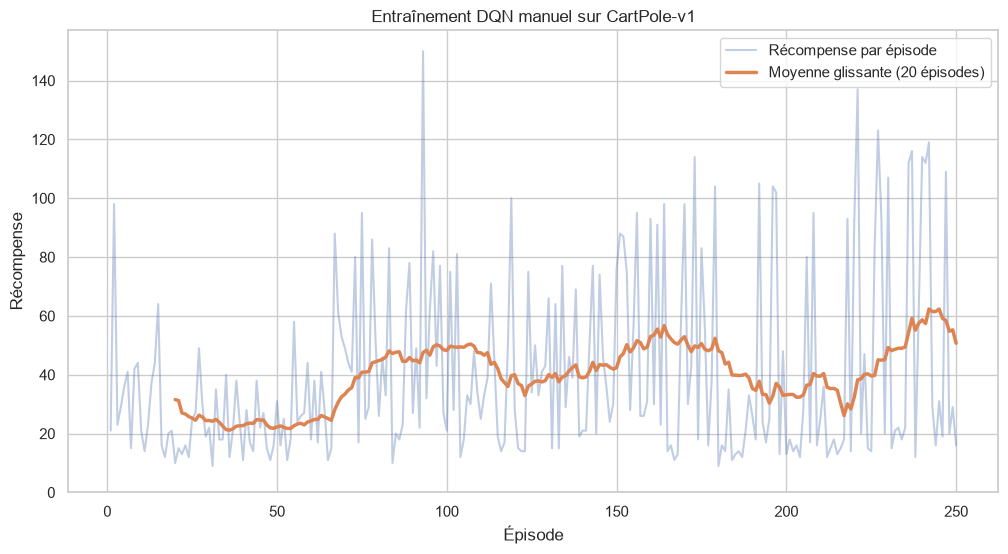

In [6]:
window = 20
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(12, 6))
sns.lineplot(x=range(1, len(episode_rewards) + 1), y=episode_rewards, label="Récompense par épisode", alpha=0.35)
sns.lineplot(x=range(window, len(episode_rewards) + 1), y=moving_average, label=f"Moyenne glissante ({window} épisodes)", linewidth=2.5)
plt.title("Entraînement DQN manuel sur CartPole-v1")
plt.xlabel("Épisode")
plt.ylabel("Récompense")
plt.ylim(bottom=0)
plt.legend()
plt.show()

## Étape 3 - Entraîner un DQN avec Stable-Baselines3

Stable-Baselines3 fournit déjà les composants importants : réseau, replay buffer, target network, stratégie d'exploration, entraînement, évaluation et sauvegarde.

In [7]:
from stable_baselines3 import DQN as SB3DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor


sb3_env = Monitor(gym.make("CartPole-v1"))
model = SB3DQN("MlpPolicy", sb3_env, verbose=1, tensorboard_log="./logs/", seed=SEED)

model.learn(total_timesteps=25_000)

mean_reward, std_reward = evaluate_policy(model, sb3_env, n_eval_episodes=100, deterministic=True)
print(f"Récompense moyenne sur 100 épisodes : {mean_reward:.2f} +/- {std_reward:.2f}")

model.save("dqn_cartpole")
print("Modèle sauvegardé dans dqn_cartpole.zip")

sb3_env.close()

Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to ./logs/DQN_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23       |
|    ep_rew_mean      | 23       |
|    exploration_rate | 0.965    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 12125    |
|    time_elapsed     | 0        |
|    total_timesteps  | 92       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 27       |
|    ep_rew_mean      | 27       |
|    exploration_rate | 0.918    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2981     |
|    time_elapsed     | 0        |
|    total_timesteps  | 216      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.514    |
|    n_updates        | 28       |
----------------------------------
--------------